# Caso clima en Australia

## Etapa 1: Entender el negocio

La oficina de meteorología de commonwealth en australia nos a dado acceso a este data set para que a travez de tecnicas de computacion como machine learning podamos buscar patrones y poder sacar conclusiones respecto a el clima de  Australia.
Aqui podemos vizualizar los datos los cuales nos entregaron para su analizis los cuales se hubican en el documento weatherAUS

$$
\begin{aligned}
&\begin{array}{cccc}
\hline \hline \text { Dato } & \text { Descripción } \\
\hline \text{ Fecha } & \text { fecha de la observación}  \\
\hline \text{Ubicación } & \text {ubicación de la estación meteorológica } \\
\hline \text{MinTemp } & \text { temperatura mínima en grados Celsius} \\
\hline \text{ MaxTemp} & \text {temperatura máxima en grados Celsius } \\
\hline \text{Lluvia } & \text {cantidad de lluvia registrada ese día en mm. } \\
\hline \text{ Evaporacion} & \text { evaporación (mm) en 24 horas} \\
\hline \text{ Sol} & \text { número de horas de sol brillante en el día} \\
\hline \text{ DirRafaga} & \text { dirección de la ráfaga de viento más fuerte en 24 horas.} \\
\hline \text{ VelRafaga} & \text {velocidad (km/hr) de la ráfaga de viento más fuerte en 24 horas. } \\
\hline \text{ Dir9am} & \text {dirección del viento a las 9am } \\
\hline \text{Dir3pm } & \text {dirección del viento a las 3pm } \\
\hline \text{Vel9am } & \text { velocidad (km/hr) del viento a las 9am} \\
\hline \text{Vel3pm } & \text { velocidad (km/hr) del viento a las 3pm} \\
\hline \text{ Hum9am} & \text { porcentaje de humedad a las 9am} \\
\hline \text{ Hum3pm} & \text {porcentaje de humedad a las 3pm } \\
\hline \text{ Pres9am} & \text { presión atmosférica (hpa) a nivel del mar a las 9am} \\
\hline \text{ Pre3pm} & \text {presión atmosférica (hpa) a nivel del mar a las 3pm } \\
\hline \text{ Nub9am} & \text { fración del cielo cubierto por nubes a las 9am. Se mide en "octavos", de manera que un valor 0 indica cielo totalmente despejado y 8, cielo totalmente cubierto.} \\
\hline \text{Nub3pm } & \text {fración del cielo cubierto por nubes a las 3pm. Se mide en "octavos", de manera que un valor 0 indica cielo totalmente despejado y 8, cielo totalmente cubierto. } \\
\hline \text{ Temp9am} & \text {temperatura en grados celsius a las 9am } \\
\hline \text{Temp3pm} & \text { temperatura en grados celsius a las 3pm} \\
\hline \text{ LluviaHoy} & \text { variable indicadora que toma el valor 1 si la precipitación en mm. en las últimas 24 hrs. excede 1 mm. y 0 si no.} \\
\hline \text{ RISK_MM} & \text { La cantidad de lluvia. Una especie de medida del "riesgo".} \\
\hline \text{LluviaMan} & \text { variable indicadora que toma el valor 1 si al día siguiente llovió y 0 si no.} \\
\end{array}
\end{aligned}
$$

El objetivo es saber si en alguna ciudad lluvio o no al dia siguiente y con la variable de riego saber si la cantidad de mm caidos fue un riesgo o no para ese dia.

### KPIs
1.   En que ciudad caen mas mm de lluvia al dia.
2.   Promedio mayor de humedad registrada.
3.   En que ciudad se registra la mayor cantidad de horas de sol al dia.
4.   En que fecha se registran las mayores precipitaciones en mm.
5.  En que ciudad es mas probable que llueva despues de un dia soleado.

##Etapa 2 : comprension de los datos

Podemos vizualizar las distintas librerias a importar ademas de la carga del data set

In [1]:
!pip install category_encoders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 1.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mt
import category_encoders as ce
import sklearn as sk
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from matplotlib import pyplot as plt

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/Mineria de datos/caso australia/weatherAUS.csv"
df = pd.read_csv(path)

----------------------------------------------------------------------------------------------------------------------------------------------------------------------



In [5]:
#Aqui podemos ver la cantidad de filas y columnas que hay en el data set
df.shape

(142193, 24)

In [6]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [7]:
#En esta sentencia se puede apreciar la cantidad de datos nulos que se encuentran en el dataframe especificada por columnas
df.isnull().sum()

Date                 0
Location             0
MinTemp            637
MaxTemp            322
Rainfall          1406
Evaporation      60843
Sunshine         67816
WindGustDir       9330
WindGustSpeed     9270
WindDir9am       10013
WindDir3pm        3778
WindSpeed9am      1348
WindSpeed3pm      2630
Humidity9am       1774
Humidity3pm       3610
Pressure9am      14014
Pressure3pm      13981
Cloud9am         53657
Cloud3pm         57094
Temp9am            904
Temp3pm           2726
RainToday         1406
RISK_MM              0
RainTomorrow         0
dtype: int64

In [8]:
#Podemos apreciar los nombre de las distintas columnas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')

In [9]:
def bar_plot(variable):
    # get feature
    var = df[variable]
    # count number of categorical variable(value/sample)
    varValue = var.value_counts()

    # visualize
    plt.figure(figsize = (9,3))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frecuencia")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

### Analisis de la variable Risk_mm

In [10]:
#Medidas de tendencia central de la cantida de lluvia caida
df["RISK_MM"].describe()

count    142193.000000
mean          2.360682
std           8.477969
min           0.000000
25%           0.000000
50%           0.000000
75%           0.800000
max         371.000000
Name: RISK_MM, dtype: float64

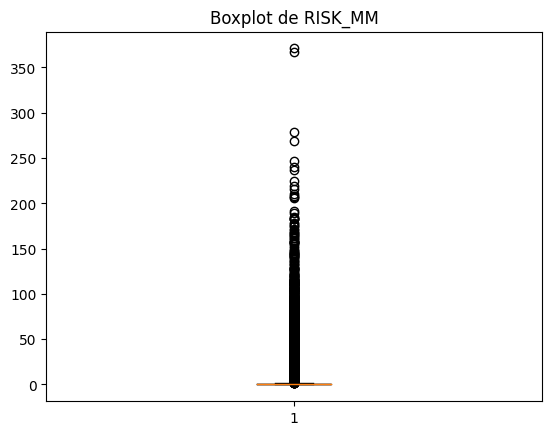

In [11]:
#En este codigo podemos ver la formacion de un boxplot para ver la distribucion cuantitativa de los datos
plt.ticklabel_format(style='plain', axis='y')
plt.boxplot(df['RISK_MM'])
plt.title('Boxplot de RISK_MM')
plt.show()

In [12]:
#En este boxplot se puede apreciar si existen valores atipicos en la variable de risk_mm, los cuales se podrian eliminar o se podria ajustar con el metodo de los intercuatiles.

In [13]:
Q1 = df['RISK_MM'].quantile(0.25)
Q3 = df['RISK_MM'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_filtrado = df[(df['RISK_MM'] >= limite_inferior) & (df['RISK_MM'] <= limite_superior)]

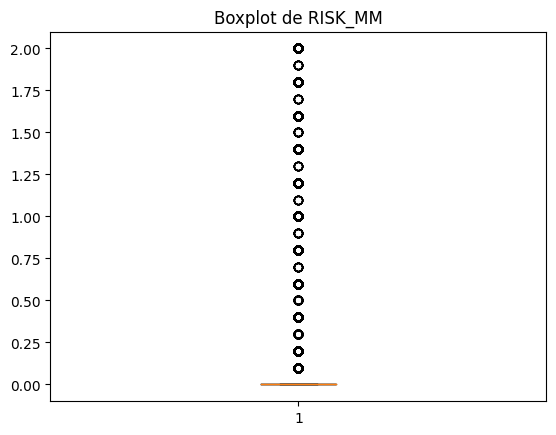

In [14]:
plt.ticklabel_format(style='plain', axis='y')
plt.boxplot(df_filtrado['RISK_MM'])
plt.title('Boxplot de RISK_MM')
plt.show()

In [15]:
#En esta fila se ve el promedio de la variable risk_mm
df["RISK_MM"].mean()

2.3606816087993083

In [16]:
#En esta fila se ve la media de la variable risk_mm
df["RISK_MM"].median()

0.0

In [17]:
#En esta fila se ve la moda de la variable risk_mm
df["RISK_MM"].mode()

0    0.0
Name: RISK_MM, dtype: float64

In [18]:
#En esta fila se ve la variaza de la variable risk_mm
df["RISK_MM"].var()

71.87595953878188

In [19]:
#En esta fila se ve la variacion estandar de la variable risk_mm
df["RISK_MM"].std()

8.477969069227717

### Analisis de la variable Rainfall

In [20]:
df["Humidity9am"].describe()

count    140419.000000
mean         68.843810
std          19.051293
min           0.000000
25%          57.000000
50%          70.000000
75%          83.000000
max         100.000000
Name: Humidity9am, dtype: float64

### Analsis de la variable Rain tomorrow

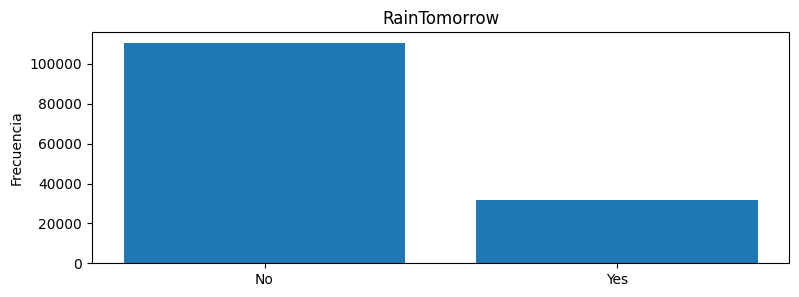

RainTomorrow: 
 RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


In [21]:
bar_plot("RainTomorrow")

In [22]:
#Este es un bar plot donde se muestra la cantidad donde no lluvio al dia siguiente y donde si llovio

In [ ]:
#Este codigo se realiza para poder ver la relacion entre los distintos datos que hay
sns.heatmap(
    data=df.corr(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot=True,
    annot_kws = {'size':5}
)

In [27]:
#En este mapa de correlacion se puede aprecia rque existe una correlacion directa entre la temp3pm y la tempmax y tambien entre la temp9am y tempmin, ademas de una correlacion
#indirecta o inversa entre cloud9am y 3pm con sunshine que son las horas de sol en 24 horas.

##Fase 3 preparacion de datos
 Aca se evalua los valores nulos y como tratarlos para las fases futuras

In [28]:
#las variables con valores nulos se utilizara knn-imputer para asignacion de valores, en las variables WindGustDir, WindDir9am, WindDir3pm se utilizara el label encoder para el reemplazo
#de los valores categoricos a valores numericos, por ultimo las variables RainToday y RainTomorrow se utilizara el binary encode para el reemplazo de variables categoricas a 0 y 1.

In [29]:
#Se crea un objeto de KNN imputer. con 5 vecinos y parámetro weights = uniform.
knn_imputer = KNNImputer(n_neighbors=5, weights="uniform")

In [30]:
df[['MinTemp']] = knn_imputer.fit_transform(df[['MinTemp']])

In [31]:
df[['MaxTemp']] = knn_imputer.fit_transform(df[['MaxTemp']])

In [32]:
df[['Evaporation']] = knn_imputer.fit_transform(df[['Evaporation']])
df['Evaporation'] = pd.Series([round(val, 2) for val in df['Evaporation']])

In [33]:
df[['Sunshine']] = knn_imputer.fit_transform(df[['Sunshine']])

In [34]:
df[['Rainfall']] = knn_imputer.fit_transform(df[['Rainfall']])

In [35]:
df[['WindGustSpeed']] = knn_imputer.fit_transform(df[['WindGustSpeed']])

In [36]:
df[['WindSpeed9am']] = knn_imputer.fit_transform(df[['WindSpeed9am']])

In [37]:
df[['WindSpeed3pm']] = knn_imputer.fit_transform(df[['WindSpeed3pm']])

In [38]:
df[['Humidity9am']] = knn_imputer.fit_transform(df[['Humidity9am']])

In [39]:
df[['Humidity3pm']] = knn_imputer.fit_transform(df[['Humidity3pm']])

In [40]:
df[['Pressure9am']] = knn_imputer.fit_transform(df[['Pressure9am']])

In [41]:
df[['Pressure3pm']] = knn_imputer.fit_transform(df[['Pressure3pm']])

In [42]:
df[['Cloud9am']] = knn_imputer.fit_transform(df[['Cloud9am']])

In [43]:
df[['Cloud3pm']] = knn_imputer.fit_transform(df[['Cloud3pm']])

In [44]:
df[['Temp9am']] = knn_imputer.fit_transform(df[['Temp9am']])

In [45]:
df[['Temp3pm']] = knn_imputer.fit_transform(df[['Temp3pm']])

In [46]:
df['WindGustDir'].unique()

array(['W', 'WNW', 'WSW', 'NE', 'NNW', 'N', 'NNE', 'SW', 'ENE', 'SSE',
       'S', 'NW', 'SE', 'ESE', nan, 'E', 'SSW'], dtype=object)

In [47]:
wind = {'W':'1','WNW':'2','WSW':'3','NNW':'4','N':'5','NNE':'6','SW':'7','ENE':'8','SSE':'9','S':'10','NW':'11','SE':'12','ESE':'13','E':'14','SSW':'14'}

In [48]:
df['WindGustDir'] = df['WindGustDir'].map(wind)
df['WindDir9am'] = df['WindDir9am'].map(wind)
df['WindDir3pm'] = df['WindDir3pm'].map(wind)

In [49]:
df[['WindGustDir']] = knn_imputer.fit_transform(df[['WindGustDir']])

In [50]:
df[['WindDir9am']] = knn_imputer.fit_transform(df[['WindDir9am']])
df[['WindDir3pm']] = knn_imputer.fit_transform(df[['WindDir3pm']])

In [51]:
df['RainTomorrow'].unique()

array(['No', 'Yes'], dtype=object)

In [52]:
rain = {'No':'0','Yes':'1'}

In [53]:
df['RainToday'] = df['RainToday'].map(rain)
df['RainTomorrow'] = df['RainTomorrow'].map(rain)

In [54]:
df[['RainToday']] = knn_imputer.fit_transform(df[['RainToday']])
df[['RainTomorrow']] = knn_imputer.fit_transform(df[['RainTomorrow']])

In [55]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,5.47,7.624853,1.000000,44.0,1.0,...,22.0,1007.7,1007.1,8.000000,4.503167,16.9,21.8,0.0,0.0,0.0
1,2008-12-02,Albury,7.4,25.1,0.0,5.47,7.624853,2.000000,44.0,4.0,...,25.0,1010.6,1007.8,4.437189,4.503167,17.2,24.3,0.0,0.0,0.0
2,2008-12-03,Albury,12.9,25.7,0.0,5.47,7.624853,3.000000,46.0,1.0,...,30.0,1007.6,1008.7,4.437189,2.000000,21.0,23.2,0.0,0.0,0.0
3,2008-12-04,Albury,9.2,28.0,0.0,5.47,7.624853,7.955327,24.0,12.0,...,16.0,1017.6,1012.8,4.437189,4.503167,18.1,26.5,0.0,1.0,0.0
4,2008-12-05,Albury,17.5,32.3,1.0,5.47,7.624853,1.000000,41.0,8.0,...,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,0.0,0.2,0.0


In [56]:
df['Location'].unique()

array(['Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree',
       'Newcastle', 'NorahHead', 'NorfolkIsland', 'Penrith', 'Richmond',
       'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown',
       'Wollongong', 'Canberra', 'Tuggeranong', 'MountGinini', 'Ballarat',
       'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura',
       'Nhil', 'Portland', 'Watsonia', 'Dartmoor', 'Brisbane', 'Cairns',
       'GoldCoast', 'Townsville', 'Adelaide', 'MountGambier', 'Nuriootpa',
       'Woomera', 'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport',
       'Perth', 'SalmonGums', 'Walpole', 'Hobart', 'Launceston',
       'AliceSprings', 'Darwin', 'Katherine', 'Uluru'], dtype=object)

In [57]:
ciudades = {'Albury':'1','BadgerysCreek':'2','Cobar':'3','CoffsHarbour':'4','Moree':'5','Newcastle':'6','NorahHead':'7','NorfolkIsland':'8','Penrith':'9','Richmond':'10','Sydney':'11','SydneyAirport':'12','WaggaWagga':'13','Williamtown':'14','Wollongong':'15','Canberra':'16','Tuggeranong':'17','MountGinini':'18','Ballarat':'19','Bendigo':'20','Sale':'21','MelbourneAirport':'22','Melbourne':'23','Mildura':'24','Nhil':'25','Portland':'26','Watsonia':'27','Dartmoor':'28','Brisbane':'29','Cairns':'30','GoldCoat':'31','Townsville':'32','Adelaide':'33','MountGambier':'34','Nuriootpa':'35','Woomera':'36','Albany':'37','Witchcliffe':'38','PearceRAAF':'39','PerthAirport':'40','Perth':'41','SalmonGums':'42','Walpole':'43','Hobart':'44','Launceston':'45','AliceSprings':'46','Darwin':'47','Katherine':'48','Uluru':'49'}

In [58]:
df['Location'] = df['Location'].map(ciudades)

In [59]:
df[['Location']] = knn_imputer.fit_transform(df[['Location']])

In [60]:
#convierte el date en datetime64
df['Date'] = pd.to_datetime(df['Date'])

In [61]:
#En este apartado separamos los datos de datetime para poder trabajarlos de mejor manera
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

In [62]:
df.drop(['Date'],axis = 1, inplace =True)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       142193 non-null  float64
 1   MinTemp        142193 non-null  float64
 2   MaxTemp        142193 non-null  float64
 3   Rainfall       142193 non-null  float64
 4   Evaporation    142193 non-null  float64
 5   Sunshine       142193 non-null  float64
 6   WindGustDir    142193 non-null  float64
 7   WindGustSpeed  142193 non-null  float64
 8   WindDir9am     142193 non-null  float64
 9   WindDir3pm     142193 non-null  float64
 10  WindSpeed9am   142193 non-null  float64
 11  WindSpeed3pm   142193 non-null  float64
 12  Humidity9am    142193 non-null  float64
 13  Humidity3pm    142193 non-null  float64
 14  Pressure9am    142193 non-null  float64
 15  Pressure3pm    142193 non-null  float64
 16  Cloud9am       142193 non-null  float64
 17  Cloud3pm       142193 non-nul

Division del entrenamiento
En este codigo dividimos el data set ademas de que agregamos la variable objetivo para poder modelarlo


In [64]:
from sklearn.model_selection import train_test_split

X = df.drop('Rainfall', axis=1)  #Aqui borramos la viariable objetivo
y = df['Rainfall']  # Aqui asigno la variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=40)

In [65]:
from sklearn.model_selection import train_test_split
df_clasi = df.copy()
X_clasi = df_clasi.drop('RainTomorrow', axis=1)  #Aqui borramos la viariable objetivo
y_clasi = df_clasi['RainTomorrow']  # Aqui asigno la variable objetivo

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_clasi, y_clasi, test_size=0.20, random_state=40)

In [66]:
from sklearn.preprocessing import StandardScaler

columns_to_exclude = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location', 'day', 'month', 'year']

# Separar las columnas a excluir
X_to_scale = df.drop(columns=columns_to_exclude)
X_excluded = df[columns_to_exclude]

# Estandarizar las columnas seleccionadas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_to_scale)

# Convertir de nuevo a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X_to_scale.columns)

# Combinar las columnas estandarizadas con las excluidas
X_final = pd.concat([X_scaled_df, X_excluded.reset_index(drop=True)], axis=1)

## Fase 4 Modelamiento(Regresion)

Linear Regression

In [67]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

Decision Trees

In [68]:
from sklearn import tree
modelo2 = tree.DecisionTreeRegressor()
modelo2.fit(X_train, y_train)

DecisionTreeRegressor()

Random Forest Regressor

In [69]:
from sklearn.ensemble import RandomForestRegressor
modelo3 = RandomForestRegressor(n_estimators=100, random_state=42)
modelo3.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

## Fase 4 Modelamiento(Clasificacion)

Random Forest Classifier

In [70]:
from sklearn.ensemble import RandomForestClassifier
modelo4 = RandomForestClassifier(n_estimators=100)
modelo4.fit(X_train1, y_train1)

RandomForestClassifier()

Support Vector Machine (SVM)

In [71]:
from sklearn.svm import SVC
modelo5 = SVC(kernel='linear', probability=True, random_state=42)
modelo5.fit(X_train1, y_train1)

SVC(kernel='linear', probability=True, random_state=42)

## Fase 4 Modelamiento (no supervisado)

In [72]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,day,month,year
0,1.0,13.4,22.9,0.6,5.47,7.624853,1.000000,44.0,1.0,2.0,...,8.000000,4.503167,16.9,21.8,0.0,0.0,0.0,1,12,2008
1,1.0,7.4,25.1,0.0,5.47,7.624853,2.000000,44.0,4.0,3.0,...,4.437189,4.503167,17.2,24.3,0.0,0.0,0.0,2,12,2008
2,1.0,12.9,25.7,0.0,5.47,7.624853,3.000000,46.0,1.0,3.0,...,4.437189,2.000000,21.0,23.2,0.0,0.0,0.0,3,12,2008
3,1.0,9.2,28.0,0.0,5.47,7.624853,7.955327,24.0,12.0,14.0,...,4.437189,4.503167,18.1,26.5,0.0,1.0,0.0,4,12,2008
4,1.0,17.5,32.3,1.0,5.47,7.624853,1.000000,41.0,8.0,11.0,...,7.000000,8.000000,17.8,29.7,0.0,0.2,0.0,5,12,2008


### K-means

In [73]:
#Se importa los elementos necesarios para utilizar los clusters,el silhouette_score y pca
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


#se crena tres Clustering sobre los datos x_final
kmeans = KMeans(n_clusters=3, random_state=40)
kmeans_labels = kmeans.fit_predict(X_final)

# Calcular Silhouette Score para K-means
silhouette_avg_kmeans = silhouette_score(X_final, kmeans_labels)
print(f"Silhouette Score para K-means: {silhouette_avg_kmeans}")

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Silhouette Score para K-means: 0.2604142659409414


### DBSCAN

In [74]:
#El siguiente codigo busca el mejor resultado para el clustering utilizando para ello el mejor Silhouette Score ademas de ajustarlo al DBSCAN,atravez de un bucles dando los mejores resultados.
import numpy as np

# Función para ajustar DBSCAN y calcular el Silhouette Score
def evaluate_dbscan(X, eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(X)

    # Filtrar ruido
    dbscan_labels_filtered = dbscan_labels[dbscan_labels != -1]
    X_filtered = X[dbscan_labels != -1]

    if len(set(dbscan_labels_filtered)) > 1:
        silhouette_avg = silhouette_score(X_filtered, dbscan_labels_filtered)
        return silhouette_avg, dbscan_labels
    else:
        return -1, dbscan_labels

# Ajustar parámetros en un bucle
best_silhouette = -1
best_eps = 0.5
best_min_samples = 5
best_labels = None

eps_values = np.arange(0.2, 1.2, 0.2)
min_samples_values = range(3, 10)

for eps in eps_values:
    for min_samples in min_samples_values:
        silhouette_avg, dbscan_labels = evaluate_dbscan(X_final, eps, min_samples)
        print(f"eps: {eps}, min_samples: {min_samples}, Silhouette Score: {silhouette_avg}")
        if silhouette_avg > best_silhouette:
            best_silhouette = silhouette_avg
            best_eps = eps
            best_min_samples = min_samples
            best_labels = dbscan_labels

print(f"Mejores parámetros - eps: {best_eps}, min_samples: {best_min_samples}, Mejor Silhouette Score: {best_silhouette}")


eps: 0.2, min_samples: 3, Silhouette Score: -1
eps: 0.2, min_samples: 4, Silhouette Score: -1
eps: 0.2, min_samples: 5, Silhouette Score: -1
eps: 0.2, min_samples: 6, Silhouette Score: -1
eps: 0.2, min_samples: 7, Silhouette Score: -1
eps: 0.2, min_samples: 8, Silhouette Score: -1
eps: 0.2, min_samples: 9, Silhouette Score: -1
eps: 0.4, min_samples: 3, Silhouette Score: -1
eps: 0.4, min_samples: 4, Silhouette Score: -1
eps: 0.4, min_samples: 5, Silhouette Score: -1
eps: 0.4, min_samples: 6, Silhouette Score: -1
eps: 0.4, min_samples: 7, Silhouette Score: -1
eps: 0.4, min_samples: 8, Silhouette Score: -1
eps: 0.4, min_samples: 9, Silhouette Score: -1
eps: 0.6000000000000001, min_samples: 3, Silhouette Score: -1
eps: 0.6000000000000001, min_samples: 4, Silhouette Score: -1
eps: 0.6000000000000001, min_samples: 5, Silhouette Score: -1
eps: 0.6000000000000001, min_samples: 6, Silhouette Score: -1
eps: 0.6000000000000001, min_samples: 7, Silhouette Score: -1
eps: 0.6000000000000001, min_sam

In [75]:
# Añadir etiquetas al DataFrame
X_final['KMeans_Labels'] = kmeans_labels
X_final['DBSCAN_Labels'] = dbscan_labels

### PCA

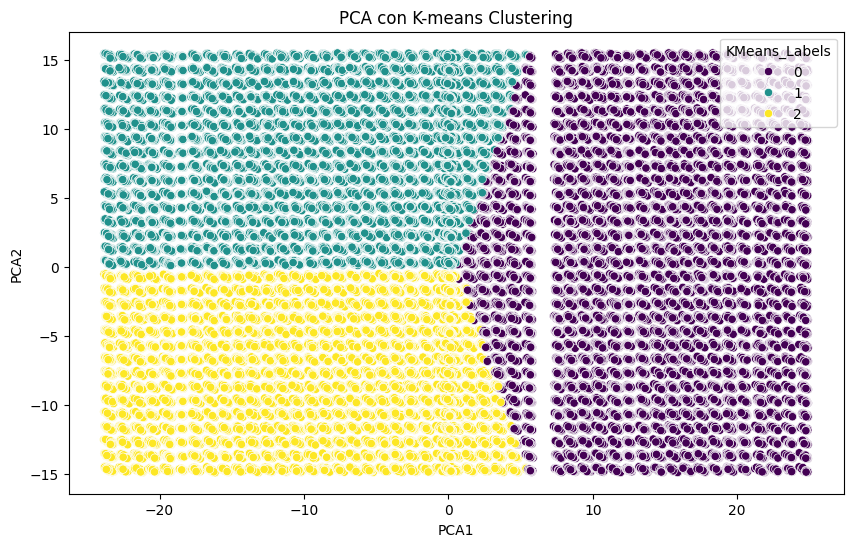

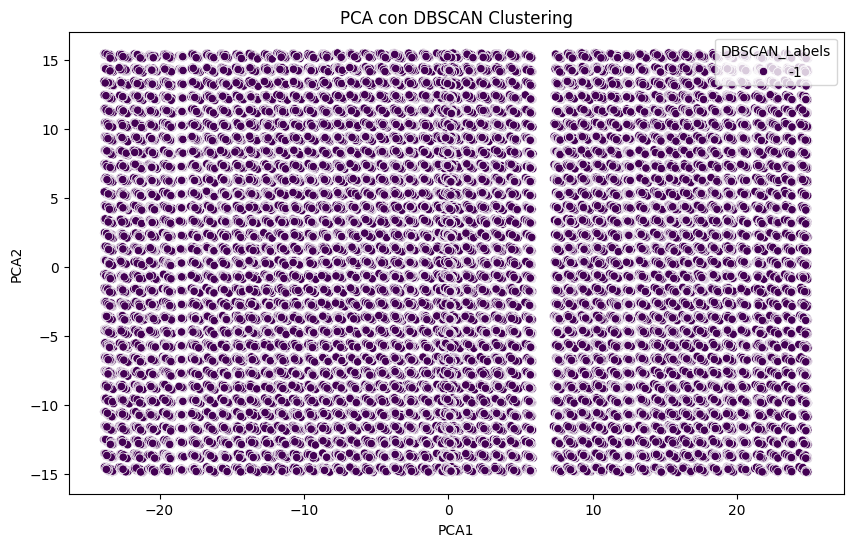

In [76]:
#La utilizacion de PCA es para reducir la dimensionalidad del conjunto de datos separandolos en dos componentes principales,luego crea DataFrames con los resultados de PCA y las etiquetas de clustering para finalmente graficar los resultados usando gráficos de dispersión

# Aplicar PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_final.drop(columns=['KMeans_Labels', 'DBSCAN_Labels']))

# Convertir a DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
X_pca_df['KMeans_Labels'] = X_final['KMeans_Labels']
X_pca_df['DBSCAN_Labels'] = X_final['DBSCAN_Labels']

# Graficar los resultados de PCA con K-means
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_pca_df, x='PCA1', y='PCA2', hue='KMeans_Labels', palette='viridis')
plt.title('PCA con K-means Clustering')
plt.show()

# Graficar los resultados de PCA con DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(data=X_pca_df, x='PCA1', y='PCA2', hue='DBSCAN_Labels', palette='viridis')
plt.title('PCA con DBSCAN Clustering')
plt.show()


## Fase 5 Comprobacion del modelo(Regresion)

In [77]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

Linear Regression

In [78]:
y_pred = modelo.predict(X_test)

In [79]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R2 score):", r2)

Error cuadrático medio (MSE): 49.66555166046164
Coeficiente de determinación (R2 score): 0.30083437482594677


Decision Trees

In [80]:
y_pred2 = modelo2.predict(X_test)

In [81]:
mse = mean_squared_error(y_test, y_pred2)
r2 = r2_score(y_test, y_pred2)

print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R2 score):", r2)

Error cuadrático medio (MSE): 91.19731917437322
Coeficiente de determinación (R2 score): -0.2838280970008591


Random Forest Regressor

In [82]:
y_pred3 = modelo3.predict(X_test)

In [83]:
mse = mean_squared_error(y_test, y_pred3)
r2 = r2_score(y_test, y_pred3)

print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R2 score):", r2)

Error cuadrático medio (MSE): 40.66703550096699
Coeficiente de determinación (R2 score): 0.42751077256946524


## Fase 5 Comprobacion del modelo(Clasificacion)

In [84]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

Random Forest Classifier

In [85]:
y_pred4 = modelo4.predict(X_test1)

In [86]:
mse = mean_squared_error(y_test1, y_pred4)
r2 = r2_score(y_test1, y_pred4)

print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R2 score):", r2)

Error cuadrático medio (MSE): 0.0
Coeficiente de determinación (R2 score): 1.0


In [87]:
accuracy = accuracy_score(y_test1, y_pred4)
print("Precisión:", accuracy)

Precisión: 1.0


In [88]:
precision = precision_score(y_test1, y_pred4, average='binary')
print("Precisión:", precision)

Precisión: 1.0


In [89]:
recall = recall_score(y_test1, y_pred4, average='binary')
print("Sensibilidad:", recall)

Sensibilidad: 1.0


In [90]:
f1 = f1_score(y_test1, y_pred4, average='binary')
print("F1-Score:", f1)

F1-Score: 1.0


In [91]:
y_pred_proba4 = modelo4.predict_proba(X_test1)[:, 1]

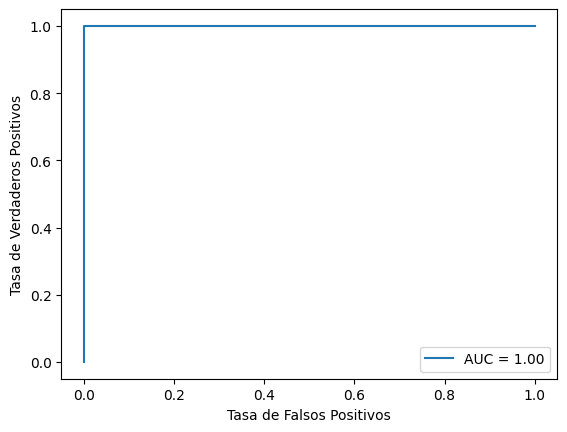

In [92]:
auc = roc_auc_score(y_test1, y_pred_proba4)

# Graficar la curva ROC
fpr, tpr, _ = roc_curve(y_test1, y_pred_proba4)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend(loc="best")
plt.show()

Support Vector Machine (SVM)

In [93]:
y_pred5 = modelo5.predict(X_test1)

In [94]:
mse = mean_squared_error(y_test1, y_pred5)
r2 = r2_score(y_test1, y_pred5)

print("Error cuadrático medio (MSE):", mse)
print("Coeficiente de determinación (R2 score):", r2)

Error cuadrático medio (MSE): 0.0
Coeficiente de determinación (R2 score): 1.0


In [95]:
accuracy = accuracy_score(y_test1, y_pred5)
print("Precisión:", accuracy)

Precisión: 1.0


In [96]:
precision = precision_score(y_test1, y_pred5, average='binary')
print("Precisión:", precision)

Precisión: 1.0


In [97]:
recall = recall_score(y_test1, y_pred5, average='binary')
print("Sensibilidad:", recall)

Sensibilidad: 1.0


In [98]:
f1 = f1_score(y_test1, y_pred5, average='binary')
print("F1-Score:", f1)

F1-Score: 1.0


In [99]:
y_pred_proba5 = modelo5.predict_proba(X_test1)[:, 1]

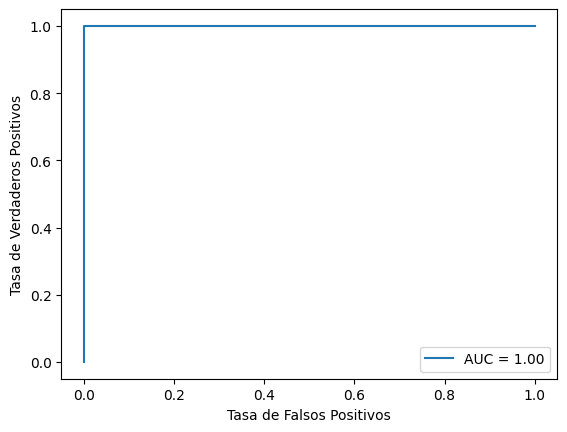

In [100]:
auc = roc_auc_score(y_test1, y_pred_proba5)

# Graficar la curva ROC
fpr, tpr, _ = roc_curve(y_test1, y_pred_proba5)
plt.plot(fpr, tpr, label="AUC = {:.2f}".format(auc))
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.legend(loc="best")
plt.show()

## Fase 6 Deployment

In [104]:
# Exportar el DataFrame a un archivo CSV
file_path = '/content/drive/MyDrive/Colab Notebooks/final_model_data.csv'
df.to_csv(file_path, index=False)

file_path

'/content/drive/MyDrive/Colab Notebooks/final_model_data.csv'